In [ ]:
import pandas as pd 
import numpy as np 
import re 
import string 

import nltk

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer 

pd.set_option('display.max_colwidth',None)

In [21]:
jira_df = pd.read_csv('../data/processed/jira_processed.csv')
jira_df = pd.read_csv("../data/processed/jira_processed.csv",keep_default_na=False)

In [22]:
jira_df.head()

,Summary,Priority,Summary_Length,Clean_Summary
0,Authentication failed when attempting Fetch command,High,52,authentication fail attempt fetch command
1,OAuth token keeps expiring,Low,26,oauth token keep expire
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71,unable start sourcetree update older version 3412
3,Keesp Asking for GitHub Login,Medium,29,keesp ask github login
4,Dark Theme - history changed files not displayed correctly,Low,58,dark theme history change file not display correctly


In [23]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(jira_df['Priority'])

In [24]:
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

{'High': np.int64(0), 'Highest': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


In [25]:
jira_df['Encoded_Priority'] = label_encoder.fit_transform(jira_df['Priority'])

In [26]:
jira_df.head()

,Summary,Priority,Summary_Length,Clean_Summary,Encoded_Priority
0,Authentication failed when attempting Fetch command,High,52,authentication fail attempt fetch command,0
1,OAuth token keeps expiring,Low,26,oauth token keep expire,2
2,Unable to start SourceTree after updating from older version to 3.4.12,Medium,71,unable start sourcetree update older version 3412,3
3,Keesp Asking for GitHub Login,Medium,29,keesp ask github login,3
4,Dark Theme - history changed files not displayed correctly,Low,58,dark theme history change file not display correctly,2


In [27]:
X = jira_df['Clean_Summary']
y = jira_df['Encoded_Priority']

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,random_state=42,stratify=y
)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [30]:
print(type(X_train))
print(type(X_test))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [31]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,max_iter=1000
)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [32]:
print(y_pred[:10])

[2 2 2 1 2 2 2 2 2 2]


In [33]:
label_encoder.inverse_transform(y_pred[:10])

array(['Low', 'Low', 'Low', 'Highest', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low'], dtype=object)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9947368421052631


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       1.00      0.92      0.96       363
     Highest       1.00      0.92      0.96       176
         Low       0.99      1.00      1.00      7556
      Medium       1.00      1.00      1.00       265

    accuracy                           0.99      8360
   macro avg       1.00      0.96      0.98      8360
weighted avg       0.99      0.99      0.99      8360



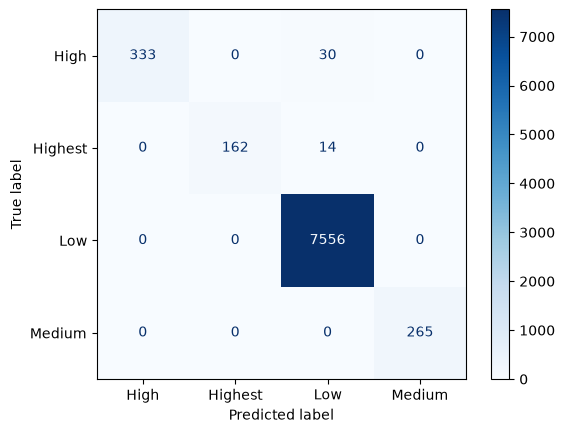

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [37]:
import joblib

joblib.dump(model, "../artifacts/logistic_regression_model.pkl")
joblib.dump(tfidf, "../artifacts/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../artifacts/label_encoder.pkl")

['../artifacts/label_encoder.pkl']

In [41]:
# Highest priority tickets from training set
X_train[y_train == "Highest"].head()

AttributeError: 'Series' object has no attribute 'nonzero'

In [43]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    jira_df["Clean_Summary"],
    jira_df["Priority"],   # <-- original priority column
    test_size=0.2,
    random_state=42,
    stratify=jira_df["Priority"]
)

In [44]:
train_df = pd.DataFrame({
    "Summary": X_train_text,
    "Priority": y_train_text
})

train_df[train_df["Priority"] == "Highest"].head(10)

,Summary,Priority
29924,fake 3410 version sourcetree,Highest
11088,sourcetree shouldnt floor cpu especially not not use,Highest
33188,unable add azure devops remote account use sourcetree 313,Highest
5133,sourcetree crash soon start,Highest
17967,update 349 3410 crash leave sourcetree unusable,Highest
30723,sourcetree crash soon start,Highest
18809,source tree application crash open,Highest
2603,source tree application crash open,Highest
17982,fake 3410 version sourcetree,Highest
18868,cannot push upgrade,Highest


In [45]:
train_df[train_df["Priority"] == "High"].head(10)

,Summary,Priority
17922,upadate embed git binary create new release,High
27309,app freeze display not respond titlebar constantly,High
20489,pull push fail atlassian logon window open sourcetree push,High
5193,sourcetree crash startup,High
40979,sign certificate expire,High
38408,diff view not show mercurial repositories,High
917,sourcetreeappcom web site point wrong version,High
35834,history view column size madness,High
40955,break link,High
18012,remote repository search not work project key not part project name,High
